#Question 1: Monte Carlo Sampling of a Localized Signal

Numerically determined value of M: 6.0000
Acceptance Rate: 0.4147


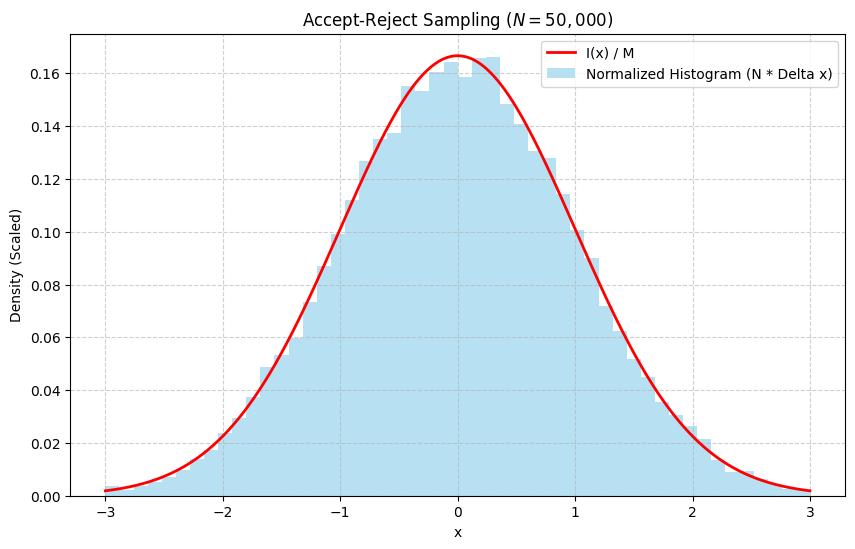

In [ ]:
# Part(a):
import numpy as np
import matplotlib.pyplot as plt

#Setup
L = 3
N = 50000
sigma = 1

grid_x = np.linspace(-L, L, 1000)

I_grid = np.exp(-grid_x**2 / (2 * sigma**2)) #Intensity equation

g_val = 1 / (2 * L)
M = np.max(I_grid / g_val)

print(f"Numerically determined value of M: {M:.4f}")

# --- 2. Accept-Reject Sampling ---
# Generate uniform proposals using np.random.uniform()
proposals = np.random.uniform(-L, L, N)

# Compute acceptance probabilities: P = I(x) / (M * g(x))
# Note: M * g(x) simplifies to 1 based on our M calculation
I_proposals = np.exp(-proposals**2 / (2 * sigma**2))
acceptance_probs = I_proposals / (M * g_val)

# Use np.random.rand() to decide acceptance
u = np.random.rand(N)
accepted_mask = u <= acceptance_probs

# Store the accepted samples
x_accepted = proposals[accepted_mask]

# Compute the acceptance rate
acceptance_rate = len(x_accepted) / N
print(f"Acceptance Rate: {acceptance_rate:.4f}")

# --- 3. Histogram and Plotting ---
# Use numpy.histogram()
counts, bin_edges = np.histogram(x_accepted, bins=50, range=(-L, L))

# Calculate bin width (Delta x)
dx = bin_edges[1] - bin_edges[0]

# Normalize by dividing by N * Delta x
# Note: This specific normalization matches I(x)/M
normalized_counts = counts / (N * dx)

# Plotting
plt.figure(figsize=(10, 6))

# Plot the normalized histogram bars
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.bar(bin_centers, normalized_counts, width=dx, alpha=0.6,
        color='skyblue', label='Normalized Histogram (N * Delta x)')

# Overlay the function I(x)
# Since the histogram is normalized by N, it scales to I(x)/M
plt.plot(grid_x, I_grid / M, 'r-', lw=2, label='I(x) / M')

plt.title(f'Accept-Reject Sampling ($N=50,000$)')
plt.xlabel('x')
plt.ylabel('Density (Scaled)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# --- Part (b): Total Signal Estimation ---

# The total area of the bounding box (Envelope Area)
# Width = 2L, Height = M * g(x) = 1
envelope_area = (2 * L) * 1

# Estimate S using the formula: S = Area * Acceptance Rate
S_estimated = envelope_area * acceptance_rate

print(f"Calculated Acceptance Rate (A): {acceptance_rate:.4f}")
print(f"Estimated Total Signal (S): {S_estimated:.4f}")

# from scipy.integrate import quad
# S_true, _ = quad(intensity, -L, L)
# print(f"True Integral Value (via SciPy): {S_true:.4f}")
# print(f"Estimation Error: {abs(S_estimated - S_true):.4f}")

Calculated Acceptance Rate (A): 0.4147
Estimated Total Signal (S): 2.4883


#Question 2: Markov Chain Relaxation and Stationary Distributions

In [ ]:
import numpy as np

# Construct the transition matrix P
P = np.array([
    [0.85, 0.10, 0.05],
    [0.15, 0.75, 0.10],
    [0.30, 0.20, 0.50]
])

# Compute eigenvalues and eigenvectors of P transposed
eigenvalues, eigenvectors = np.linalg.eig(P.T)

# Identify the eigenvector corresponding to eigenvalue 1
# We use argmin on the difference to handle potential numerical precision limits
idx = np.argmin(np.abs(eigenvalues - 1.0))
pi_stat = np.real(eigenvectors[:, idx])

# Normalize the vector so that the probabilities sum to 1
pi_stat = pi_stat / np.sum(pi_stat)

# Print stationary probabilities in the requested format
print(f"A = {pi_stat[0]:.4f}, B = {pi_stat[1]:.4f}, C = {pi_stat[2]:.4f}")

A = 0.5600, B = 0.3200, C = 0.1200


<>:39: SyntaxWarning: invalid escape sequence '\p'
<>:40: SyntaxWarning: invalid escape sequence '\p'
<>:41: SyntaxWarning: invalid escape sequence '\p'
<>:39: SyntaxWarning: invalid escape sequence '\p'
<>:40: SyntaxWarning: invalid escape sequence '\p'
<>:41: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-1882378064.py:39: SyntaxWarning: invalid escape sequence '\p'
  plt.axhline(y=pi_stat[0], color='blue', linestyle='--', alpha=0.5, label='$\pi_{stat}$ A')
/tmp/ipython-input-1882378064.py:40: SyntaxWarning: invalid escape sequence '\p'
  plt.axhline(y=pi_stat[1], color='orange', linestyle='--', alpha=0.5, label='$\pi_{stat}$ B')
/tmp/ipython-input-1882378064.py:41: SyntaxWarning: invalid escape sequence '\p'
  plt.axhline(y=pi_stat[2], color='green', linestyle='--', alpha=0.5, label='$\pi_{stat}$ C')


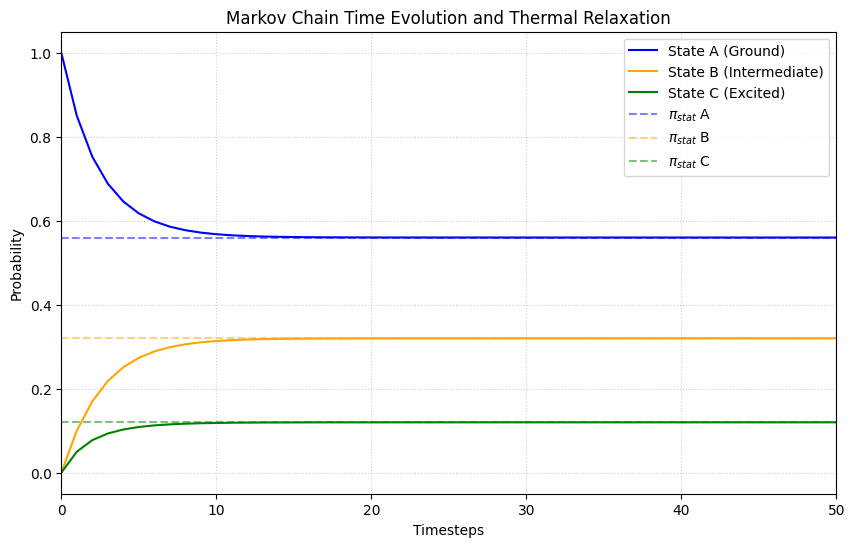

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Transition Matrix P
P = np.array([
    [0.85, 0.10, 0.05],
    [0.15, 0.75, 0.10],
    [0.30, 0.20, 0.50]
])

# Recalculate stationary distribution from Part (a) for the plot lines
vals, vecs = np.linalg.eig(P.T)
pi_stat = np.real(vecs[:, np.isclose(vals, 1)]).flatten()
pi_stat /= pi_stat.sum()

# Part (b): Simulation
# Initial state: entirely in ground state (A)
pi_t = np.array([1, 0, 0])
n_steps = 500

# Store the probabilities at every timestep
history = np.zeros((n_steps + 1, 3))
history[0] = pi_t

# Iterate using the @ operator
for t in range(n_steps):
    pi_t = pi_t @ P
    history[t+1] = pi_t

# Plotting
plt.figure(figsize=(10, 6))
time = np.arange(n_steps + 1)

plt.plot(time, history[:, 0], label='State A (Ground)', color='blue')
plt.plot(time, history[:, 1], label='State B (Intermediate)', color='orange')
plt.plot(time, history[:, 2], label='State C (Excited)', color='green')

# Add horizontal dashed lines at stationary values from Part (a)
plt.axhline(y=pi_stat[0], color='blue', linestyle='--', alpha=0.5, label='$\pi_{stat}$ A')
plt.axhline(y=pi_stat[1], color='orange', linestyle='--', alpha=0.5, label='$\pi_{stat}$ B')
plt.axhline(y=pi_stat[2], color='green', linestyle='--', alpha=0.5, label='$\pi_{stat}$ C')

plt.xlabel('Timesteps')
plt.ylabel('Probability')
plt.title('Markov Chain Time Evolution and Thermal Relaxation')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.xlim(0, 50) # Zooming in to see the relaxation more clearly
plt.show()

#Question 3: Importance Sampling for Spectral Power Estimation

Estimated Total Radiated Power (Φ): 2150.5088
Standard Error: 3.0706


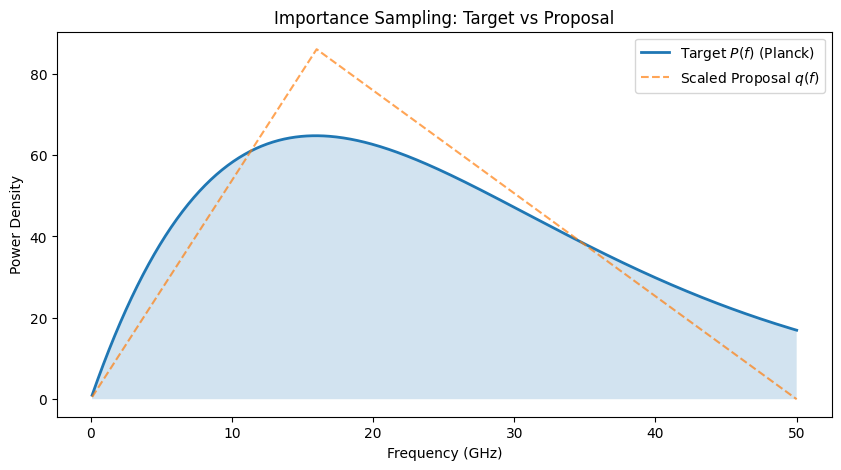

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the physical constants and the target function P(f)
T = 10
f_min, f_max = 0, 50

def P(f):
    # Handling f=0 to avoid division by zero
    with np.errstate(divide='ignore', invalid='ignore'):
        val = f**2 / (np.exp(f/T) - 1)
    return np.nan_to_num(val)

# 2. Define the Proposal Distribution q(f)
# We'll use a triangular distribution peaking at 16
peak = 16

def q_pdf(f):
    """Analytical PDF of the triangular distribution for weighting."""
    # Using numpy's logic: it's a triangle from 0 to 50 with peak at 16
    return np.where(f < peak,
                    (2*f) / (f_max * peak),
                    (2*(f_max - f)) / (f_max * (f_max - peak)))

# 3. Perform Importance Sampling
N = 100000  # Number of samples

# Step A: Sample from the proposal distribution q(f)
samples = np.random.triangular(left=f_min, mode=peak, right=f_max, size=N)

# Step B: Calculate weights w = P(f) / q(f)
weights = P(samples) / q_pdf(samples)

# Step C: The estimate is the average of the weights
phi_estimate = np.mean(weights)
standard_error = np.std(weights) / np.sqrt(N)

print(f"Estimated Total Radiated Power (Φ): {phi_estimate:.4f}")
print(f"Standard Error: {standard_error:.4f}")

# 4. Visualization
f_axis = np.linspace(0.1, 50, 500)
plt.figure(figsize=(10, 5))
plt.plot(f_axis, P(f_axis), label='Target $P(f)$ (Planck)', lw=2)
plt.plot(f_axis, q_pdf(f_axis) * phi_estimate, '--', label='Scaled Proposal $q(f)$', alpha=0.7)
plt.fill_between(f_axis, P(f_axis), alpha=0.2)
plt.title("Importance Sampling: Target vs Proposal")
plt.xlabel("Frequency (GHz)")
plt.ylabel("Power Density")
plt.legend()
plt.show()

In [ ]:
import numpy as np

# 1. Setup Parameters and Target Function
T = 10
f_min, f_max = 0, 50
N = 50000

def P(f):
    """Target spectral power density."""
    with np.errstate(divide='ignore', invalid='ignore'):
        val = f**2 / (np.exp(f/T) - 1)
    return np.nan_to_num(val)

# --- 1. Naive Estimate ---
# Sample uniformly from [0, 50]
f_naive = np.random.uniform(f_min, f_max, N)
# Compute individual weighted samples: X_i = P(f_i) * 50
weighted_samples_naive = P(f_naive) * 50

phi_naive = np.mean(weighted_samples_naive)
var_naive = np.var(weighted_samples_naive)

# --- 2. Importance Sampling Estimate ---
# Proposal: Triangular distribution peaking at f=16
peak = 16
f_is = np.random.triangular(left=f_min, mode=peak, right=f_max, size=N)

def q_pdf(f):
    """PDF of the triangular proposal distribution q(f)."""
    return np.where(f < peak,
                    (2*f) / (f_max * peak),
                    (2*(f_max - f)) / (f_max * (f_max - peak)))

# Compute individual weighted samples: X_i = P(f_i) / q(f_i)
weighted_samples_is = P(f_is) / q_pdf(f_is)

phi_is = np.mean(weighted_samples_is)
var_is = np.var(weighted_samples_is)

# --- Output Results ---
print(f"{'Method':<25} | {'Estimate (Φ)':<15} | {'Variance':<15}")
print("-" * 60)
print(f"{'Naive Monte Carlo':<25} | {phi_naive:<15.4f} | {var_naive:<15.4f}")
print(f"{'Importance Sampling':<25} | {phi_is:<15.4f} | {var_is:<15.4f}")

# Calculate Variance Reduction
reduction = var_naive / var_is
print(f"\nVariance Reduction Factor: {reduction:.2f}times")

Method                    | Estimate (Φ)    | Variance       
------------------------------------------------------------
Naive Monte Carlo         | 2142.8372       | 700083.8854    
Importance Sampling       | 2153.6129       | 2132246.5894   

Variance Reduction Factor: 0.33times
